<a href="https://colab.research.google.com/github/khanglam2110/Vietnam-Stock-Market-Spillover-Network-Structure-Analysis/blob/main/Spillover_Effect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0. Setup Environment

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import networkx as nx

## 1. Load Data

In [ ]:
df = pd.read_excel("VN30_preprocessed-2.xlsx")
df.head()

,Source.Name,Date,Price,Open,High,Low,Vol.,Change %
0,ACB.csv,2025-10-22,24800.0,25200.0,25300.0,24750.0,11000000,-0.0080
1,ACB.csv,2025-10-21,25000.0,24850.0,25300.0,24850.0,19370000,0.0081
2,ACB.csv,2025-10-20,24800.0,25600.0,25650.0,24600.0,32230000,-0.0369
3,ACB.csv,2025-10-17,25750.0,26300.0,26400.0,25750.0,16290000,-0.0209
4,ACB.csv,2025-10-16,26300.0,26400.0,26550.0,26150.0,13460000,0.0000


## 2. Basic Preprocessing

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values(['Source.Name', 'Date'])
df = df.rename(columns={
    'Source.Name': 'Ticker',
    'Vol.': 'Volume',
    'Change %': 'Change_pct'
})

In [ ]:
df.columns
df['Ticker'].unique()[:20]
df['Ticker'] = df['Ticker'].astype(str).str.replace('.csv', '', regex=False)

In [ ]:
df['Ticker'].nunique()
df['Ticker'].value_counts().head(10)

df['Ticker'].unique()
df['Ticker'] = df['Ticker'].str.replace('E6', 'M', regex=False)
df['Ticker'] = df['Ticker'].str.strip()

df['Ticker'].value_counts().head(10)

,count
Ticker,
CTG,1449
BID,1449
MBB,1449
FPT,1449
MWG,1449
MSN,1449
HDB,1449
HPG,1449
GAS,1449


## 3. Handle missing values (panel-aware)

In [ ]:
df = df.reset_index(drop=True)

missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

missing_by_ticker = df.groupby('Ticker').apply(lambda x: x.isnull().mean())

df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

df.groupby('Ticker')['Date'].agg(['min', 'max', 'count'])

/tmp/ipykernel_1029/3536761980.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_ticker = df.groupby('Ticker').apply(lambda x: x.isnull().mean())


,min,max,count
Ticker,,,
ACB,2020-01-02,2025-10-22,1444
BCM,2020-01-02,2025-10-22,1440
BID,2020-01-02,2025-10-22,1449
CTG,2020-01-02,2025-10-22,1449
DGC,2020-01-02,2025-10-22,1443
FPT,2020-01-02,2025-10-22,1449
GAS,2020-01-02,2025-10-22,1449
GVR,2020-01-02,2025-10-22,1443
HDB,2020-01-02,2025-10-22,1449


## 3.5 Exploratory Data Analysis

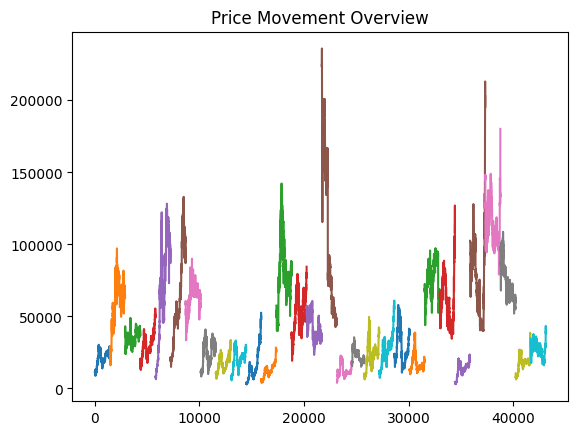

In [ ]:
# Price overview
df.groupby('Ticker')['Price'].plot(legend=False)
plt.title("Price Movement Overview")
plt.show()

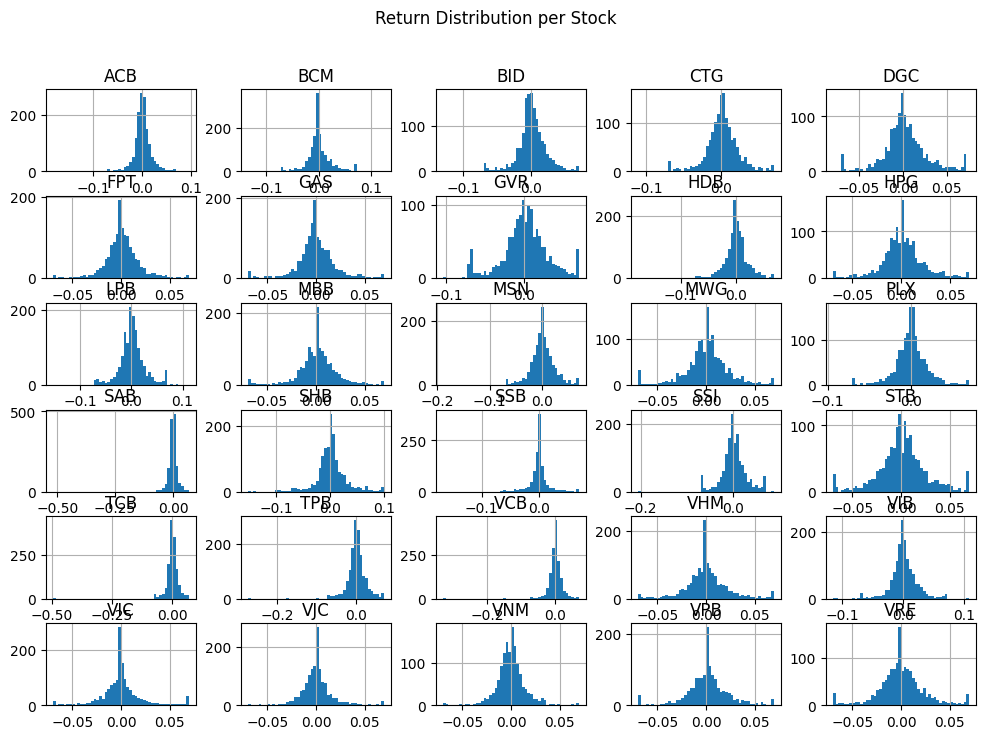

In [ ]:
# Return Distribution
returns_df.hist(bins=50, figsize=(12, 8))
plt.suptitle("Return Distribution per Stock")
plt.show()

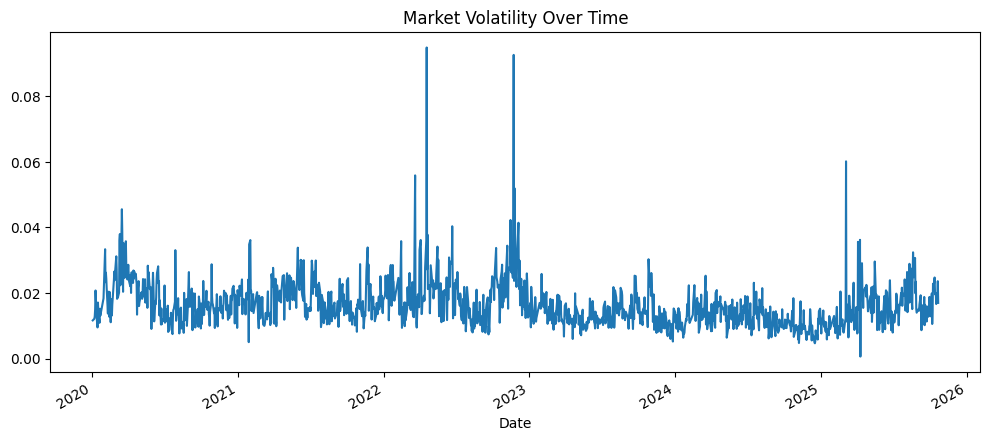

In [ ]:
# Market Volatility
market_vol = returns_df.std(axis=1)

plt.figure(figsize=(12, 5))
market_vol.plot()
plt.title("Market Volatility Over Time")
plt.show()

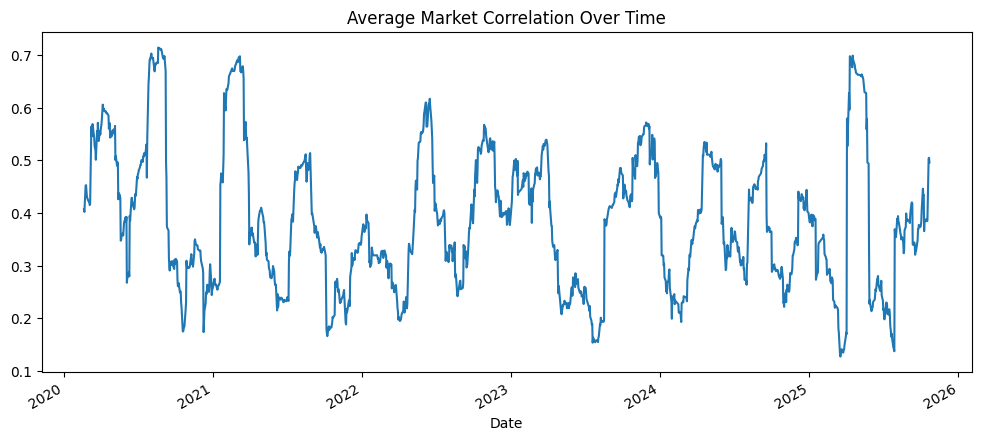

In [ ]:
# Average correlation over time
rolling_corr = returns_df.rolling(30).corr()

avg_corr = rolling_corr.groupby(level=0).mean().mean(axis=1)

plt.figure(figsize=(12, 5))
avg_corr.plot()
plt.title("Average Market Correlation Over Time")
plt.show()

In [ ]:
# Top Volatile Stocks
returns_df.std().sort_values(ascending=False).head(10)

,0
Ticker,
GVR,0.029026
SHB,0.028146
SSI,0.027674
LPB,0.026167
DGC,0.025584
TCB,0.025120
STB,0.024780
BCM,0.024720
TPB,0.023850


## 4. Feature Engineering

In [ ]:
df['Return'] = df.groupby('Ticker')['Price'].pct_change()

df = df.dropna(subset=['Return'])

returns_df = df.pivot(index='Date', columns='Ticker', values='Return')
returns_df = returns_df.dropna(axis=1, thresh=int(0.7 * len(returns_df)))
returns_df = returns_df.fillna(0)

# Filter Liquid Stocks

valid_tickers = df.groupby('Ticker')['Return'].count()
valid_tickers = valid_tickers[valid_tickers > 100].index

df = df[df['Ticker'].isin(valid_tickers)]

# Final clean return matrix

returns_df = df.pivot(index='Date', columns='Ticker', values='Return')
returns_df = returns_df.dropna(axis=1, how='all')

## 5. Correlation Matrix

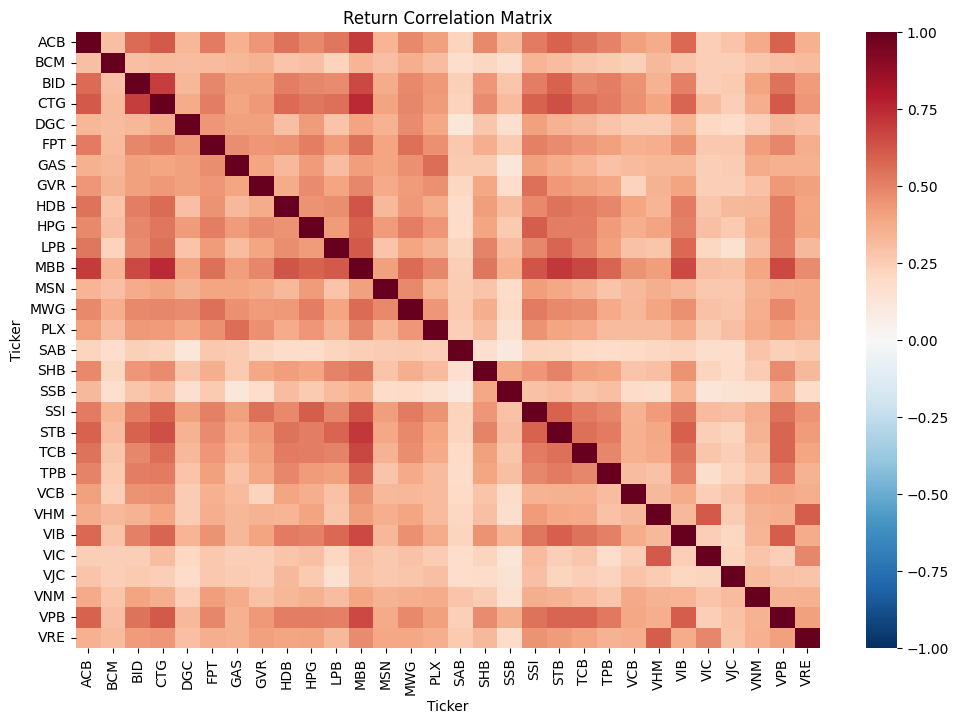

In [ ]:
corr = returns_df.corr()

# Visualization

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1
    )

plt.title("Return Correlation Matrix")
plt.show()

## 6. Correlation Matrix Checking

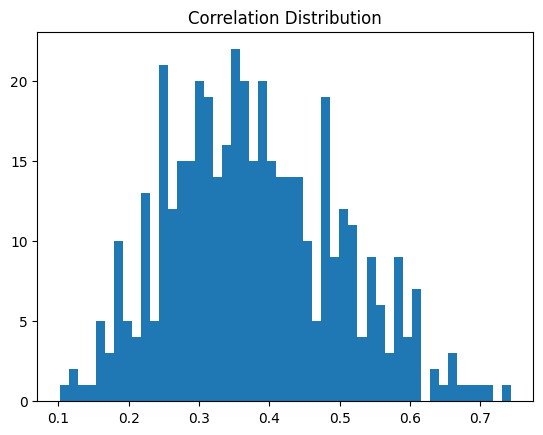

,0
Ticker,
MBB,0.532508
CTG,0.492661
SSI,0.475761
STB,0.473875
VPB,0.468244
ACB,0.467241
BID,0.461750
VIB,0.451722
HPG,0.450052


In [ ]:
# Distribution of Correlation
corr_values = corr.values[np.triu_indices_from(corr.values, k=1)]

plt.hist(corr_values, bins=50)
plt.title("Correlation Distribution")
plt.show()

# Mean correlation per stock
mean_corr = corr.mean().sort_values(ascending=False)
mean_corr.head(10)

## 7. Filter NOISE STOCKS

In [ ]:
valid_stocks = returns_df.std()
valid_stocks = valid_stocks[valid_stocks > 0.001].index

returns_df = returns_df[valid_stocks]
corr = returns_df.corr()

## 8. Clean Correlation Matrix Structure

In [ ]:
corr = corr.fillna(0)
np.fill_diagonal(corr.values, 1)

## 9. Build Network Graph

In [ ]:
G = nx.Graph()

threshold = 0.35

for i in corr.columns:
  for j in corr.columns:
    if i != j:
      w = corr.loc[i, j]
      if abs(w) > threshold:
        G.add_edge(i, j, weight=w)

from networkx.algorithms.community import greedy_modularity_communities
communities = list(greedy_modularity_communities(G))

In [ ]:
sector_map ={
    'ACB': 'Banking', 'BID': 'Banking', 'CTG': 'Banking', 'HDB': 'Banking', 'LPB': 'Banking',
    'MBB': 'Banking', 'SHB': 'Banking', 'SSB': 'Banking', 'STB': 'Banking', 'TCB': 'Banking',
    'VCB': 'Banking', 'TPB': 'Banking', 'VIB': 'Banking', 'VPB': 'Banking',
    'VIC': 'RealEstate', 'VHM': 'RealEstate', 'VRE': 'RealEstate', 'BCM': 'Industrial RealEstate',
    'HPG': 'Steel', 'DGC': 'Chemicals', 'GVR': 'Rubber',
    'GAS': 'Energy', 'PLX': 'Energy',
    'MWG': 'Retail', 'MSN': 'Consumer', 'SAB': 'Beverage', 'VNM': 'Consumer',
    'SSI': 'Securities',
    'VJC': 'Aviation',
    'FPT': 'Technology'
}

df['Sector'] = df['Ticker'].map(sector_map)
df = df.dropna(subset=['Sector'])

# Choose top stocks
top_stocks = returns_df.std().sort_values(ascending=False).head(10).index
returns_top = returns_df[top_stocks]

## 10. ADF Test (Stationary)

In [ ]:
from statsmodels.tsa.api import adfuller

for col in returns_top.columns:
  result = adfuller(returns_top[col].dropna())
  print(col, result[1])

GVR 0.0
SHB 0.0
SSI 0.0
LPB 0.0
DGC 0.0
TCB 7.322496796062383e-08
STB 0.0
BCM 2.9766793384413187e-29
TPB 0.0
VRE 0.0


In [ ]:
# Fit VAR Model

from statsmodels.tsa.api import VAR

model = VAR(returns_top.dropna())
results = model.fit(maxlags=5)

fevd = results.fevd(10)

spillover_matrix = fevd.decomp[-1]

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
# Total Spillover Index

off_diag_sum = np.sum(spillover_matrix) - np.trace(spillover_matrix)
total_sum = np.sum(spillover_matrix)

spillover_index = off_diag_sum / total_sum * 100

In [ ]:
# Degree Centrality
centrality = nx.degree_centrality(G)

centrality_df = (
    pd.DataFrame.from_dict(centrality, orient='index', columns=['centrality']).sort_values('centrality', ascending=False)
)

## 11. Heatmap Spillover

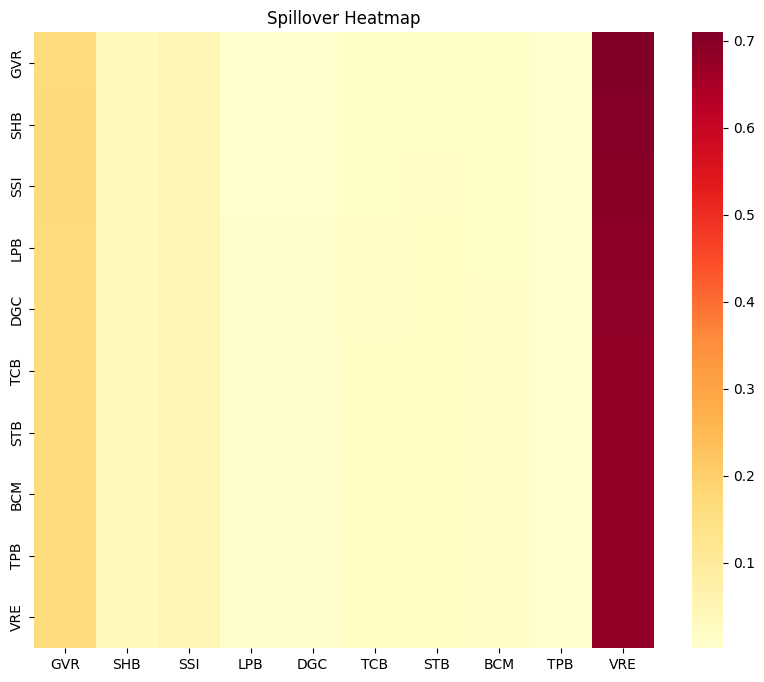

In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    spillover_matrix,
    xticklabels=top_stocks,
    yticklabels=top_stocks,
    cmap="YlOrRd"
)

plt.title("Spillover Heatmap")
plt.show()

## 12. Network (Spillover-based)

In [ ]:
G = nx.DiGraph()

for i in range(len(top_stocks)):
  for j in range(len(top_stocks)):
    if i != j:
      weight = spillover_matrix[i, j]
      if weight > 0.05:
        G.add_edge(top_stocks[j], top_stocks[i], weight=weight)

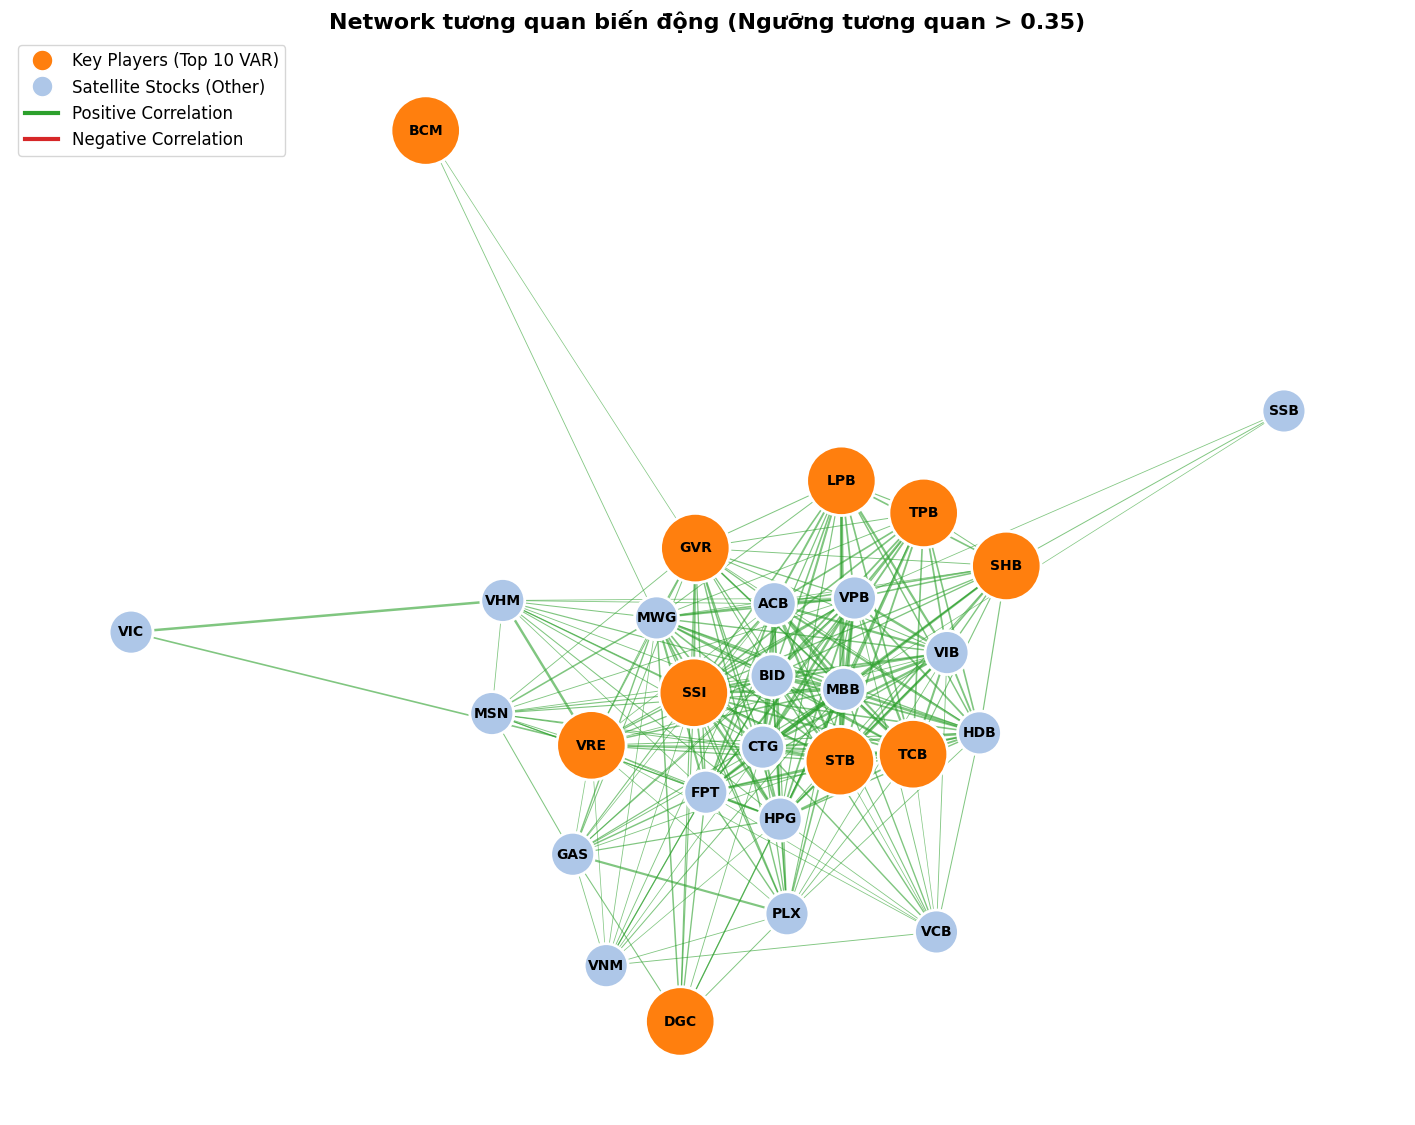

In [ ]:
# Network Visualization

graph_viz = nx.Graph() # Re-initialize graph for this visualization

corr_matrix = returns_df.corr()

threshold = 0.35
edges_data = []

stock_names = corr_matrix.columns.tolist()
for i in range(len(stock_names)):
  for j in range(i + 1, len(stock_names)):
    u, v = stock_names[i], stock_names[j]
    corr_val = corr_matrix.iloc[i, j]

    if abs(corr_val) > threshold:
      edge_color = '#2ca02c' if corr_val > 0 else '#d62728'
      width = (abs(corr_val) - threshold) * 5 + 0.5

      graph_viz.add_edge(u, v, weight=abs(corr_val), color=edge_color, width=width)

node_colors = []
node_sizes = []
node_labels = {}

for node in graph_viz.nodes():
  node_labels[node] = node
  if node in top_stocks:
    node_colors.append('#ff7f0e')
    node_sizes.append(2500)
  else:
    node_colors.append('#aec7e8')
    node_sizes.append(1000)

plt.figure(figsize=(18, 14))

pos = nx.spring_layout(graph_viz, k=0.5, iterations=100, seed=42)

nx.draw_networkx_nodes(graph_viz, pos, node_color=node_colors, node_size=node_sizes,
                       edgecolors='white', linewidths=2)
nx.draw_networkx_labels(graph_viz, pos, labels=node_labels, font_size=10, font_weight='bold')

edge_colors_list = [graph_viz[u][v]['color'] for u, v in graph_viz.edges()]
edge_widths_list = [graph_viz[u][v]['width'] for u, v in graph_viz.edges()]

nx.draw_networkx_edges(graph_viz, pos, edge_color=edge_colors_list, width=edge_widths_list, alpha=0.6)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker ='o', color='w', label=f'Key Players (Top {len(top_stocks)} VAR)',
           markerfacecolor='#ff7f0e', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='Satellite Stocks (Other)',
           markerfacecolor='#aec7e8', markersize=15),
    Line2D([0], [0], color='#2ca02c', lw=3, label='Positive Correlation'),
    Line2D([0], [0], color='#d62728', lw=3, label='Negative Correlation')
]

plt.legend(handles=legend_elements, loc='upper left', fontsize=12, frameon=True)
plt.title(f"Network tương quan biến động (Ngưỡng tương quan > {threshold})", fontsize=16, fontweight='bold')
plt.axis('off')
plt.show()